In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Copy of Student_Performance_Messy.csv")

# Display first 5 rows
df.head()

,Student_ID,Student_Name,Gender,Department,Attendance,Math_Score,Science_Score,English_Score,Final_Result
0,1,Student_001,Male,ECE,100.0,49,NaN,70.0,Pass
1,2,Student_002,Male,CSE,68.0,48,46.0,89.0,Fail
2,3,Student_003,Male,CIVIL,65.0,62,64.0,99.0,Fail
3,4,Student_004,Female,CSE,72.0,88,63.0,92.0,Fail
4,5,Student_005,Male,ECE,70.0,89,78.0,70.0,Fail


In [ ]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Student_ID     520 non-null    int64  
 1   Student_Name   520 non-null    object 
 2   Gender         512 non-null    object 
 3   Department     520 non-null    object 
 4   Attendance     511 non-null    float64
 5   Math_Score     511 non-null    object 
 6   Science_Score  511 non-null    float64
 7   English_Score  516 non-null    float64
 8   Final_Result   520 non-null    object 
dtypes: float64(3), int64(1), object(5)
memory usage: 36.7+ KB


In [ ]:
# Check missing values
df.isnull().sum()

,0
Student_ID,0
Student_Name,0
Gender,8
Department,0
Attendance,9
Math_Score,9
Science_Score,9
English_Score,4
Final_Result,0


In [ ]:
# Fill missing values with column mean
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())
df["Math_Score"] = pd.to_numeric(df["Math_Score"], errors='coerce')
df["Math_Score"] = df["Math_Score"].fillna(df["Math_Score"].mean())
df["Science_Score"] = df["Science_Score"].fillna(df["Science_Score"].mean())
df["English_Score"] = df["English_Score"].fillna(df["English_Score"].mean())

# Verify missing values
df.isnull().sum()

,0
Student_ID,0
Student_Name,0
Gender,8
Department,0
Attendance,0
Math_Score,0
Science_Score,0
English_Score,0
Final_Result,0


In [ ]:
# Total number of students
print("Total Students:", len(df))

Total Students: 520


In [ ]:
# Average marks of each subject
print("Average Math Score:", df["Math_Score"].mean())
print("Average Science Score:", df["Science_Score"].mean())
print("Average English Score:", df["English_Score"].mean())

Average Math Score: 67.0764705882353
Average Science Score: 67.41487279843443
Average English Score: 69.54263565891472


In [ ]:
# Pass percentage
pass_count = (df["Final_Result"] == "Pass").sum()
pass_percentage = (pass_count / len(df)) * 100

print("Pass Percentage:", round(pass_percentage, 2), "%")

Pass Percentage: 65.0 %


In [ ]:
# Calculate total marks
df["Total_Score"] = df["Math_Score"] + df["Science_Score"] + df["English_Score"]

# Top 5 performers
top_students = df.sort_values(by="Total_Score", ascending=False)

top_students.head()

,Student_ID,Student_Name,Gender,Department,Attendance,Math_Score,Science_Score,English_Score,Final_Result,Total_Score
309,310,Student_310,Male,CSE,72.0,100.0,86.0,99.0,Fail,285.0
419,420,Student_420,Female,CIVIL,88.0,96.0,86.0,99.0,Pass,281.0
37,38,Student_038,Male,MECH,70.0,87.0,97.0,96.0,Fail,280.0
103,104,Student_104,Female,EEE,77.0,96.0,94.0,90.0,Pass,280.0
423,424,Student_424,Femle,EEE,83.0,85.0,94.0,99.0,Pass,278.0


In [ ]:
# Department-wise average total score
department_performance = df.groupby("Department")["Total_Score"].mean()

print(department_performance)

Department
CIVIL    204.363925
CSE      208.848155
ECE      200.278409
EEE      205.226712
MECH     200.393979
Name: Total_Score, dtype: float64


In [ ]:
# Correlation between attendance and total score
correlation = df["Attendance"].corr(df["Total_Score"])

print("Correlation between Attendance and Total Score:", correlation)

Correlation between Attendance and Total Score: -0.07097931388621789


In [ ]:
# Students with Total Score less than 150
support_students = df[df["Total_Score"] < 150]

support_students

,Student_ID,Student_Name,Gender,Department,Attendance,Math_Score,Science_Score,English_Score,Final_Result,Total_Score
16,17,Student_017,Male,ECE,91.0,46.0,41.0,49.0,Pass,136.0
33,34,Student_034,Female,EEE,89.0,41.0,47.0,42.0,Pass,130.0
36,37,Student_037,Male,ECE,88.0,47.0,41.0,36.0,Pass,124.0
40,41,Student_041,Female,CSE,78.0,62.0,42.0,42.0,Pass,146.0
42,43,Student_043,Male,MECH,65.0,58.0,43.0,43.0,Fail,144.0
54,55,Student_055,Male,CIVIL,87.0,36.0,49.0,44.0,Pass,129.0
74,75,Student_075,Male,MECH,72.0,53.0,38.0,40.0,Fail,131.0
94,95,Student_095,Male,ECE,74.0,43.0,40.0,38.0,Fail,121.0
124,125,Student_125,Female,MECH,71.0,44.0,55.0,35.0,Fail,134.0
128,129,Student_129,Female,CIVIL,69.0,44.0,42.0,56.0,Fail,142.0


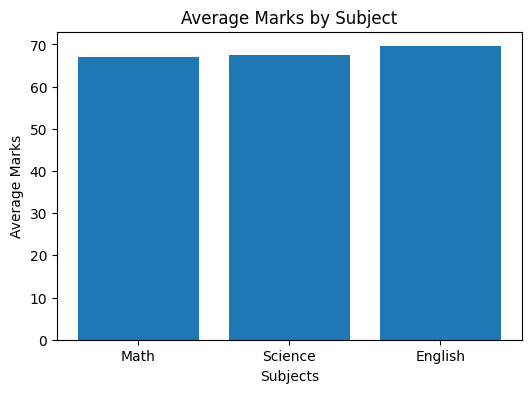

In [ ]:
import matplotlib.pyplot as plt

# Average marks for each subject
average_marks = {
    "Math": df["Math_Score"].mean(),
    "Science": df["Science_Score"].mean(),
    "English": df["English_Score"].mean()
}

plt.figure(figsize=(6,4))
plt.bar(average_marks.keys(), average_marks.values())
plt.title("Average Marks by Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()

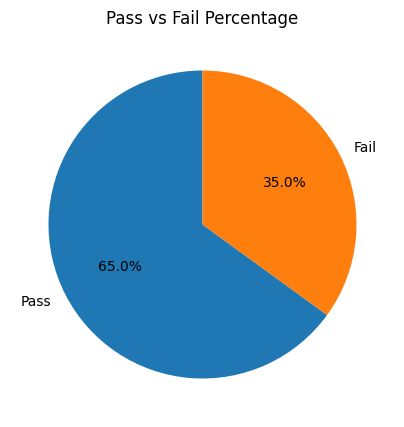

In [ ]:
# Count pass and fail students
result_counts = df["Final_Result"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(result_counts,
        labels=result_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Pass vs Fail Percentage")
plt.show()

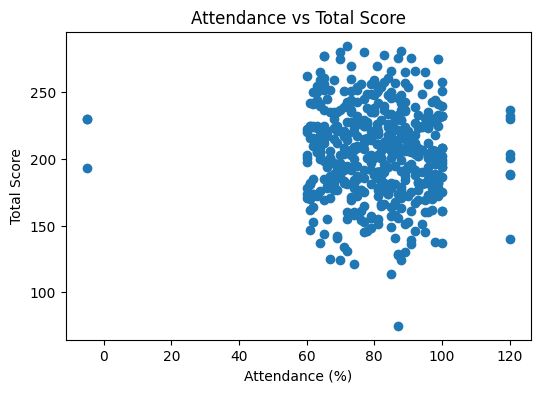

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["Attendance"], df["Total_Score"])

plt.title("Attendance vs Total Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Total Score")
plt.show()

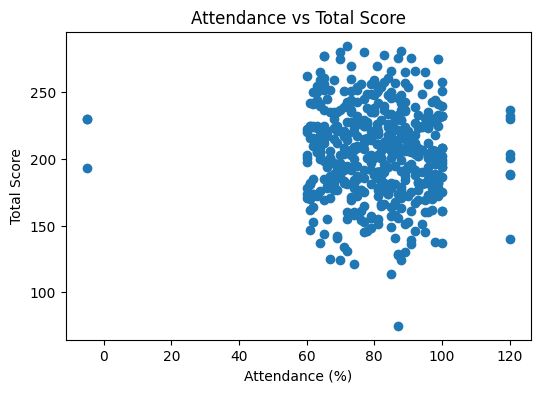

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["Attendance"], df["Total_Score"])

plt.title("Attendance vs Total Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Total Score")
plt.show()

## Resources

### Distribution of Total Scores

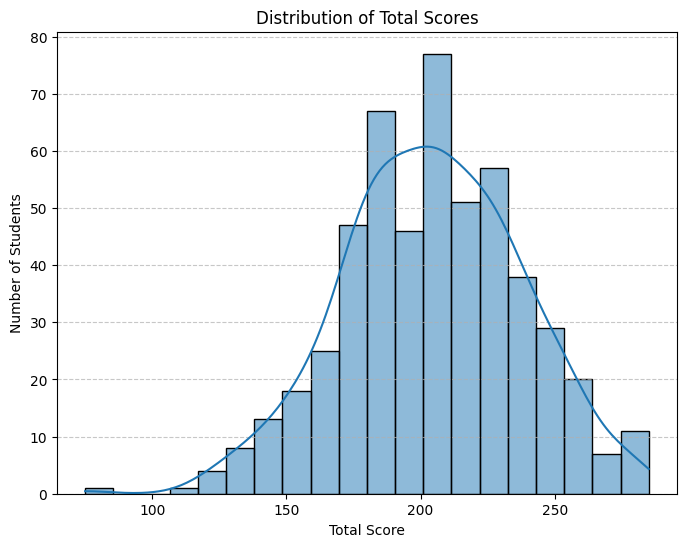

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.histplot(df['Total_Score'], bins=20, kde=True)
plt.title('Distribution of Total Scores')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Distribution of Total Scores by Gender

/tmp/ipykernel_5872/2797494394.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Gender')


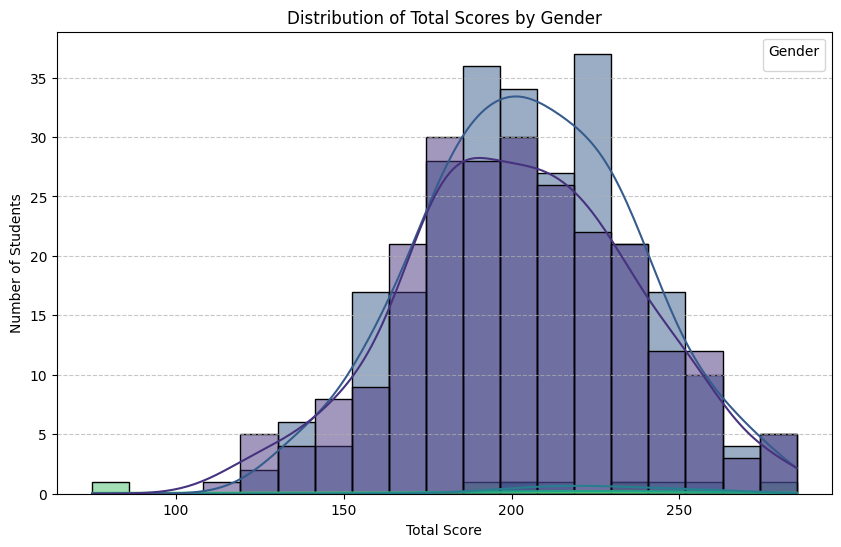

In [ ]:
# Drop rows with missing 'Gender' for clean visualization
df_gender_clean = df.dropna(subset=['Gender'])

plt.figure(figsize=(10, 6))
sns.histplot(data=df_gender_clean, x='Total_Score', hue='Gender', kde=True, palette='viridis')
plt.title('Distribution of Total Scores by Gender')
plt.xlabel('Total Score')
plt.ylabel('Number of Students')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender')
plt.show()